## Imports & Display Settings

In [1]:
# Standard imports
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning & modelling
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Pandas display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)

# Seaborn style
sns.set(style="whitegrid", font_scale=1.2)

## Load data

In [2]:
# Matches
matches = pd.read_parquet(r"Datasets/SkillCorner Premier League 24-25 data/matches_clean.parquet")

# Team lookup table
team_lookup = pd.concat([
    matches[["home_team_id","home_team_name"]].rename(columns={"home_team_id":"team_id","home_team_name":"team_name"}),
    matches[["away_team_id","away_team_name"]].rename(columns={"away_team_id":"team_id","away_team_name":"team_name"})
]).drop_duplicates()

# Event files
folder = Path(r"Datasets/SkillCorner Premier League 24-25 data\dynamic_events_pl_24\dynamic")
dfs = [pd.read_parquet(file) for file in folder.glob("*.parquet")]
events = pd.concat(dfs, ignore_index=True)

print(f"Total events: {len(events)}, Unique matches: {events['match_id'].nunique()}")

Total events: 1811078, Unique matches: 378


In [23]:
matches.head()

,id,home_team_score,away_team_score,date_time,status,home_team_side,pitch_length,pitch_width,stadium_id,stadium_name,stadium_city,stadium_capacity,home_team_id,home_team_name,home_team_short_name,home_team_acronym,home_team_kit_id,home_team_kit_team_id,home_team_kit_season,home_team_kit_name,home_team_kit_jersey_color,home_team_kit_number_color,away_team_id,away_team_name,away_team_short_name,away_team_acronym,away_team_kit_id,away_team_kit_team_id,away_team_kit_season,away_team_kit_name,away_team_kit_jersey_color,away_team_kit_number_color,home_team_coach_id,home_team_coach_first_name,home_team_coach_last_name,away_team_coach_id,away_team_coach_first_name,away_team_coach_last_name,home_team_playing_time_minutes_tip,home_team_playing_time_minutes_otip,away_team_playing_time_minutes_tip,away_team_playing_time_minutes_otip,competition_edition_id,competition_edition_competition,competition_edition_season,competition_edition_name,competition_round_id,competition_round_name,competition_round_round_number,competition_round_potential_overtime,ball_trackable_object,home_team_coach,away_team_coach
0,1650385,1,0,2024-08-16T19:00:00Z,closed,"[left_to_right, right_to_left]",105,68,63,Old Trafford,Manchester,75635.0,31,Manchester United,Manchester U,MUN,549,31,"{'end_year': 2019, 'id': 5, 'name': '2018/2019', 'start_year': 2018}",Home,#ff0000,#ffffff,48,Fulham,Fulham,FUL,7510,48,"{'end_year': 2022, 'id': 20, 'name': '2022', 'start_year': 2022}",Home,#ffffff,#000000,326.0,Ralf,Rangnick,699.0,Scott,Parker,27.94,25.15,25.15,27.94,895,"{'age_group': 'adult', 'area': 'ENG', 'gender': 'male', 'id': 1, 'name': 'Premier League'}","{'end_year': 2025, 'id': 95, 'name': '2024/2025', 'start_year': 2024}",ENG - Premier League - 2024/2025,7,Round 1,1,False,55,None,None
1,1650961,0,2,2024-08-17T11:30:00Z,closed,"[left_to_right, right_to_left]",106,66,481,Portman Road Stadium,Ipswich,30311.0,752,Ipswich Town,Ipswich Town,IPS,3796,752,"{'end_year': 2021, 'id': 7, 'name': '2020/2021', 'start_year': 2020}",Home,#0000d9,#ffffff,2,Liverpool Football Club,Liverpool,LIV,250,2,"{'end_year': 2018, 'id': 4, 'name': '2017/2018', 'start_year': 2017}",home,#c10021,#ffffff,585.0,Paul,Lambert,49.0,Jürgen,Klopp,19.85,31.06,31.06,19.85,895,"{'age_group': 'adult', 'area': 'ENG', 'gender': 'male', 'id': 1, 'name': 'Premier League'}","{'end_year': 2025, 'id': 95, 'name': '2024/2025', 'start_year': 2024}",ENG - Premier League - 2024/2025,7,Round 1,1,False,55,None,None
2,1651700,1,2,2024-08-17T16:30:00Z,closed,"[left_to_right, right_to_left]",105,68,52,Stade Olympique de Londres,London,60000.0,37,West Ham United,West Ham,WHU,142,37,"{'end_year': 2018, 'id': 4, 'name': '2017/2018', 'start_year': 2017}",home,#882739,#ffffff,39,Aston Villa,Aston Villa,AVL,3027,39,"{'end_year': 2021, 'id': 7, 'name': '2020/2021', 'start_year': 2020}",Away,#ffffff,#0a163e,872.0,David,Moyes,327.0,Steven,Gerrard,24.86,28.81,28.81,24.86,895,"{'age_group': 'adult', 'area': 'ENG', 'gender': 'male', 'id': 1, 'name': 'Premier League'}","{'end_year': 2025, 'id': 95, 'name': '2024/2025', 'start_year': 2024}",ENG - Premier League - 2024/2025,7,Round 1,1,False,55,None,None
3,1651701,2,0,2024-08-17T14:00:00Z,closed,"[left_to_right, right_to_left]",105,68,69,Emirates,London,60272.0,3,Arsenal Football Club,Arsenal,ARS,533,3,"{'end_year': 2019, 'id': 5, 'name': '2018/2019', 'start_year': 2018}",Home alt,#ff0000,#ffffff,52,Wolverhampton Wanderers,Wolverhampton,WOL,10391,52,"{'end_year': 2024, 'id': 28, 'name': '2023/2024', 'start_year': 2023}",Away,#fbff00,#000000,869.0,Mikel,Arteta,696.0,Bruno,Lage,25.47,26.23,26.23,25.47,895,"{'age_group': 'adult', 'area': 'ENG', 'gender': 'male', 'id': 1, 'name': 'Premier League'}","{'end_year': 2025, 'id': 95, 'name': '2024/2025', 'start_year': 2024}",ENG - Premier League - 2024/2025,7,Round 1,1,False,55,None,None
4,1651702,0,3,2024-08-17T14:00:00Z,closed,"[right_to_left, left_to_right]",101,68,89,Goodison Park,Liverpool,39571.0,41,Everton,Everton,EVE,253,41,"{'end_year': 2018

## Check player_targeted_xpass_completion

In [3]:
# Check missing values per event type
for event_type in ["player_possession", "passing_option"]:
    ev = events[events["event_type"] == event_type]
    total = len(ev)
    non_missing = ev["player_targeted_xpass_completion"].notna().sum()
    print(f"{event_type}: {non_missing}/{total} non-missing ({non_missing/total:.2%})")

player_possession: 306381/362853 non-missing (84.44%)
passing_option: 0/939059 non-missing (0.00%)


## Preprocessing and Feature Engineering

In [4]:
# 1️⃣ Filter passing options
pass_cols = [
    "match_id",
    "associated_player_possession_event_id",
    "player_id",        # receiver
    "player_name",
    "xthreat",
    "targeted",
    "x_start",          # receiver x
    "y_start",          # receiver y
    "interplayer_angle",
    "interplayer_distance",
    "interplayer_direction",
    "channel_start",
    "third_start",
    "penalty_area_start",
    "organised_defense"
]

passing_options = events[events["event_type"] == "passing_option"][pass_cols].copy()

# Rename receiver coordinates
passing_options = passing_options.rename(columns={"x_start": "receiver_x", "y_start": "receiver_y"})

# Convert numeric features
passing_options["xthreat"] = pd.to_numeric(passing_options["xthreat"], errors="coerce").fillna(0)

# 2️⃣ Merge possession info
possession_cols = [
    "match_id", "event_id", "player_id", "player_name",
    "x_start", "y_start", "player_targeted_id", "player_targeted_xpass_completion"
]
possession_events = events[events["event_type"] == "player_possession"][possession_cols].copy()
possession_events = possession_events.rename(columns={
    "event_id": "possession_event_id",
    "player_id": "passer_id",
    "player_name": "passer_name",
    "x_start": "passer_x",
    "y_start": "passer_y",
    "player_targeted_id": "target_receiver_id",
    "player_targeted_xpass_completion": "xpass_from_model"
})

passing_options = passing_options.merge(
    possession_events,
    left_on=["match_id", "associated_player_possession_event_id"],
    right_on=["match_id", "possession_event_id"],
    how="left"
)

# 3️⃣ Assign xpass_completion for targeted receiver
mask = passing_options["player_id"] == passing_options["target_receiver_id"]
passing_options["xpass_completion"] = None
passing_options.loc[mask, "xpass_completion"] = passing_options.loc[mask, "xpass_from_model"]

# 4️⃣ Feature engineering
passing_options["interplayer_angle_sin"] = np.sin(passing_options["interplayer_angle"])
passing_options["interplayer_angle_cos"] = np.cos(passing_options["interplayer_angle"])
passing_options["passer_receiver_x_diff"] = passing_options["receiver_x"] - passing_options["passer_x"]
passing_options["passer_receiver_y_diff"] = passing_options["receiver_y"] - passing_options["passer_y"]

# Drop unused columns
passing_options = passing_options.drop(columns=["xpass_from_model", "possession_event_id", "target_receiver_id"])

## Define Feature Groups

In [5]:
# Tabular / categorical / additional / spatial
tabular_features = ["xthreat", "interplayer_distance"]
categorical_features = ["interplayer_direction", "channel_start", "third_start", "penalty_area_start", "organised_defense"]
additional_features = ["interplayer_angle_sin", "interplayer_angle_cos", "passer_receiver_x_diff", "passer_receiver_y_diff"]
spatial_features = ["receiver_x", "receiver_y", "passer_x", "passer_y"]
features_all = tabular_features + categorical_features + additional_features

## Split Dataset for Model Training

In [6]:
target = "xpass_completion"
train_df = passing_options[passing_options[target].notna()].copy()
predict_df = passing_options[passing_options[target].isna()].copy()
train_df[target] = train_df[target].astype(float)

# One-hot encode categorical features
X = pd.get_dummies(train_df[features_all])
y = train_df[target]
X_pred = pd.get_dummies(predict_df[features_all]).reindex(columns=X.columns, fill_value=0)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=14)

## Train Tree Models

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=14),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05, max_depth=6, random_state=14),
    "XGBoost": xgb.XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=14, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(n_estimators=500, learning_rate=0.03, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=14, n_jobs=-1),
    "CatBoost": cb.CatBoostRegressor(iterations=500, learning_rate=0.03, depth=6, verbose=0, random_state=14)
}

results = []
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = np.clip(model.predict(X_test), 0, 1)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    results.append((name, rmse, mae))
    print(f"{name} evaluation: RMSE={rmse:.4f}, MAE={mae:.4f}\n{'-'*40}")

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE"])
best_model_name = results_df.sort_values("RMSE").iloc[0]["Model"]
best_model = models[best_model_name]
print("Best tree model:", best_model_name)

# Predict missing xpass_completion
predict_df["predicted_xpass"] = np.clip(best_model.predict(X_pred), 0, 1)
passing_options.loc[predict_df.index, "predicted_xpass"] = predict_df["predicted_xpass"]

Training Linear Regression...
Linear Regression evaluation: RMSE=0.1387, MAE=0.0977
----------------------------------------
Training Random Forest...
Random Forest evaluation: RMSE=0.1071, MAE=0.0668
----------------------------------------
Training Hist Gradient Boosting...
Hist Gradient Boosting evaluation: RMSE=0.1040, MAE=0.0649
----------------------------------------
Training XGBoost...
XGBoost evaluation: RMSE=0.1036, MAE=0.0645
----------------------------------------
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002190 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1560
[LightGBM] [Info] Number of data points in the train set: 282711, number of used features: 21
[LightGBM] [Info] Start training from score 0.865602
LightGBM evaluation: RMSE=0.1042, MAE=0.0651
----------------------------------------
Trai

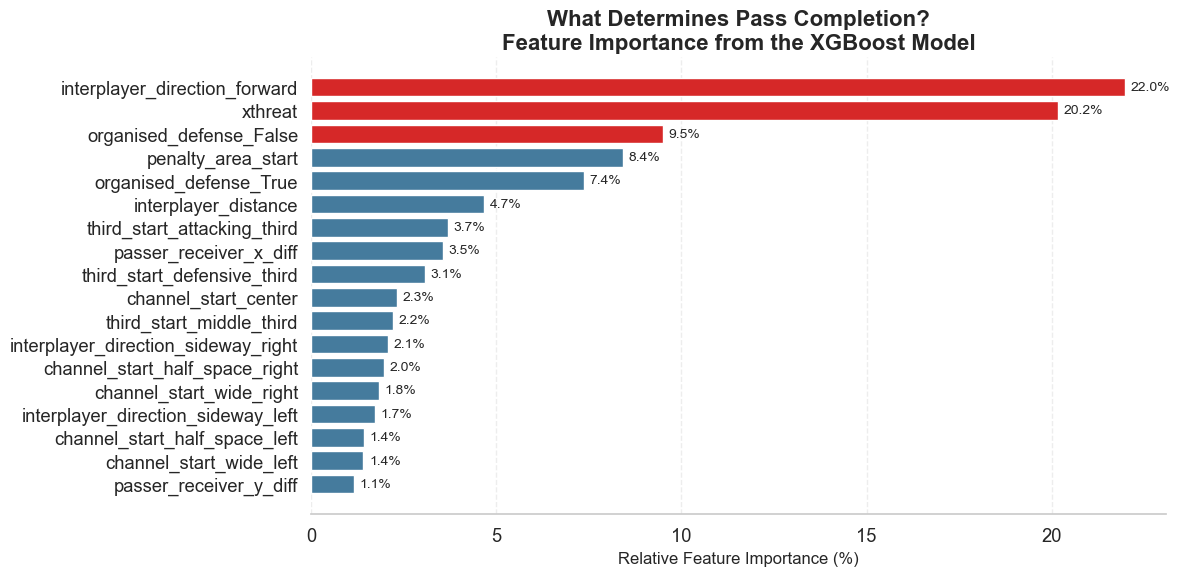

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# ================================
# PREPARE FEATURE IMPORTANCE DATA
# ================================

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.feature_importances_
})

# Convert to percentage importance
feat_imp["importance_pct"] = feat_imp["importance"] / feat_imp["importance"].sum() * 100

# Keep top features
feat_imp = (
    feat_imp
    .sort_values("importance_pct", ascending=False)
    .head(18)
    .sort_values("importance_pct")
)

# ================================
# PLOT STYLE
# ================================

sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

# Highlight top 3 features
colors = ["#d62828" if i >= len(feat_imp)-3 else "#457b9d" for i in range(len(feat_imp))]

bars = plt.barh(
    feat_imp["feature"],
    feat_imp["importance_pct"],
    color=colors
)

# ================================
# LABEL BARS
# ================================

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.15,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center",
        fontsize=10
    )

# ================================
# TITLES
# ================================

plt.title(
    "What Determines Pass Completion?\nFeature Importance from the XGBoost Model",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Relative Feature Importance (%)", fontsize=12)
plt.ylabel("")

# ================================
# CLEAN LOOK
# ================================

plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.grid(axis="y", alpha=0)

sns.despine(left=True, bottom=False)

plt.tight_layout()

plt.show()

In [ ]:
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer for the trained XGBoost model
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_train)

# Plot
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_train,
    plot_type="dot",
    max_display=15,
    show=False
)

plt.title(
    "What Drives Pass Completion?\nSHAP Feature Impact (XGBoost Model)",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()
plt.show()

## Neural Networks

In [10]:
# 1️⃣ Align tabular + spatial features with rows that have xpass_completion
train_df_nn = train_df.dropna(subset=spatial_features).copy()  # keep only rows with valid spatial data

# Tabular features (one-hot encoded categorical + numeric features)
X_tab_full = pd.get_dummies(train_df_nn[features_all]).astype(np.float32)

# Spatial features (numeric only)
X_sp_full = train_df_nn[spatial_features].astype(np.float32)

# Target
y_full = train_df_nn[target].astype(np.float32).values.reshape(-1, 1)

# Convert to tensors
X_tab_t = torch.tensor(X_tab_full.values, dtype=torch.float32)
X_sp_t = torch.tensor(X_sp_full.values, dtype=torch.float32)
y_t = torch.tensor(y_full, dtype=torch.float32)

# 2️⃣ Train/validation split
X_tab_tr, X_tab_val, X_sp_tr, X_sp_val, y_tr, y_val = train_test_split(
    X_tab_t, X_sp_t, y_t, test_size=0.1, random_state=14
)

# DataLoaders
train_loader = DataLoader(TensorDataset(X_tab_tr, X_sp_tr, y_tr), batch_size=2048, shuffle=True)
val_loader = DataLoader(TensorDataset(X_tab_val, X_sp_val, y_val), batch_size=2048, shuffle=False)

# 3️⃣ Define Neural Network
class SpatialPassNN(nn.Module):
    def __init__(self, tab_dim, spatial_dim, tab_hidden=128, spatial_hidden=64, dropout=0.3):
        super().__init__()
        self.tab_branch = nn.Sequential(
            nn.Linear(tab_dim, tab_hidden), nn.ReLU(),
            nn.BatchNorm1d(tab_hidden), nn.Dropout(dropout),
            nn.Linear(tab_hidden, tab_hidden//2), nn.ReLU()
        )
        self.spatial_branch = nn.Sequential(
            nn.Linear(spatial_dim, spatial_hidden), nn.ReLU(),
            nn.BatchNorm1d(spatial_hidden), nn.Dropout(dropout),
            nn.Linear(spatial_hidden, spatial_hidden//2), nn.ReLU()
        )
        self.combined = nn.Sequential(
            nn.Linear(tab_hidden//2 + spatial_hidden//2, 64), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(64,1), nn.Sigmoid()
        )
    def forward(self, x_tab, x_spatial):
        t = self.tab_branch(x_tab)
        s = self.spatial_branch(x_spatial)
        return self.combined(torch.cat([t,s], dim=1))

In [11]:
param_grid = {"tab_hidden":[64,128], "spatial_hidden":[32,64], "dropout":[0.2,0.3], "lr":[0.001,0.0005]}
best_val_rmse = float('inf')
best_params = None
best_model_state = None

for params in ParameterGrid(param_grid):
    model = SpatialPassNN(tab_dim=X_tab_t.shape[1], spatial_dim=X_sp_t.shape[1],
                          tab_hidden=params["tab_hidden"], spatial_hidden=params["spatial_hidden"],
                          dropout=params["dropout"])
    optimizer = optim.Adam(model.parameters(), lr=params["lr"])
    criterion = nn.MSELoss()
    patience = 5
    patience_counter = 0
    for epoch in range(20):
        # Training
        model.train()
        for xb_tab, xb_sp, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb_tab, xb_sp), yb)
            loss.backward()
            optimizer.step()
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb_tab, xb_sp, yb in val_loader:
                val_loss += criterion(model(xb_tab, xb_sp), yb).item() * xb_tab.size(0)
        val_rmse = np.sqrt(val_loss / len(val_loader.dataset))
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_params = params
            best_model_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

print("Best NN params:", best_params, "Val RMSE:", best_val_rmse)

Best NN params: {'dropout': 0.2, 'lr': 0.001, 'spatial_hidden': 32, 'tab_hidden': 64} Val RMSE: 0.10255866215244851


## Neural Network Prediction

In [12]:
# Recreate best NN and predict missing xpass_completion
best_nn = SpatialPassNN(tab_dim=X_tab_t.shape[1], spatial_dim=X_sp_t.shape[1],
                        tab_hidden=best_params["tab_hidden"], spatial_hidden=best_params["spatial_hidden"],
                        dropout=best_params["dropout"])
best_nn.load_state_dict(best_model_state)
best_nn.eval()

# Align X_pred for NN (tabular + spatial features)
X_pred_tab_full = pd.get_dummies(predict_df[features_all]).reindex(columns=X_tab_full.columns, fill_value=0).astype(np.float32)
X_pred_sp_full = predict_df[spatial_features].astype(np.float32)

X_pred_tab_t = torch.tensor(X_pred_tab_full.values, dtype=torch.float32)
X_pred_sp_t = torch.tensor(X_pred_sp_full.values, dtype=torch.float32)

with torch.no_grad():
    preds_nn = best_nn(X_pred_tab_t, X_pred_sp_t).numpy().flatten()

predict_df["predicted_xpass_nn"] = np.clip(preds_nn, 0, 1)
passing_options.loc[predict_df.index, "predicted_xpass_nn"] = predict_df["predicted_xpass_nn"]

## Model Evaluation on Known xpass_completion

In [13]:
# Use the same rows as NN training (with valid spatial features)
eval_df = train_df_nn.copy()

# Tabular features for evaluation
X_tab_eval = pd.get_dummies(eval_df[features_all]).reindex(columns=X_tab_full.columns, fill_value=0).astype(np.float32)

# Spatial features for evaluation
X_sp_eval = eval_df[spatial_features].astype(np.float32)

# True target
y_eval = eval_df[target].values

# Tree model predictions
tree_preds_eval = best_model.predict(X_tab_eval)
tree_rmse = np.sqrt(mean_squared_error(y_eval, tree_preds_eval))
tree_mae = mean_absolute_error(y_eval, tree_preds_eval)

# Neural network predictions
X_tab_t_eval = torch.tensor(X_tab_eval.values, dtype=torch.float32)
X_sp_t_eval = torch.tensor(X_sp_eval.values, dtype=torch.float32)

with torch.no_grad():
    nn_preds_eval = best_nn(X_tab_t_eval, X_sp_t_eval).numpy().flatten()

nn_rmse = np.sqrt(mean_squared_error(y_eval, nn_preds_eval))
nn_mae = mean_absolute_error(y_eval, nn_preds_eval)

print(f"Model comparison on known xpass_completion:")
print(f"{best_model_name} -> RMSE: {tree_rmse:.4f}, MAE: {tree_mae:.4f}")
print(f"Neural Network -> RMSE: {nn_rmse:.4f}, MAE: {nn_mae:.4f}")

Model comparison on known xpass_completion:
XGBoost -> RMSE: 0.1031, MAE: 0.0644
Neural Network -> RMSE: 0.1039, MAE: 0.0639


## Final Prediction for Missing Values

In [14]:
# Tree model prediction
preds = np.clip(best_model.predict(X_pred), 0, 1)
predict_df["predicted_xpass"] = preds
passing_options["predicted_xpass"] = None
passing_options.loc[predict_df.index, "predicted_xpass"] = preds

print("Predictions added. Range:", passing_options["predicted_xpass"].min(), passing_options["predicted_xpass"].max())

# Final analysis-ready dataset
passing_options.head()

Predictions added. Range: 0.17446550726890564 1.0


,match_id,associated_player_possession_event_id,player_id,player_name,xthreat,targeted,receiver_x,receiver_y,interplayer_angle,interplayer_distance,interplayer_direction,channel_start,third_start,penalty_area_start,organised_defense,passer_id,passer_name,passer_x,passer_y,xpass_completion,interplayer_angle_sin,interplayer_angle_cos,passer_receiver_x_diff,passer_receiver_y_diff,predicted_xpass,predicted_xpass_nn
0,1650385,8_1,12941,E. Smith Rowe,0.0013,False,-3.81,7.10,51.81,9.36,sideway_left,center,middle_third,False,True,13068,S. Lukić,-9.6,-0.26,None,0.999655,0.026276,5.79,7.36,0.978647,0.987027
1,1650385,8_1,5794,K. Tete,0.0001,False,-12.58,-19.43,-99.34,18.67,sideway_right,half_space_right,middle_third,False,True,13068,S. Lukić,-9.6,-0.26,None,0.928727,0.370764,-2.98,-19.17,1.0,0.993582
2,1650385,8_1,4504,I. Diop,0.0000,True,-22.51,-6.97,-155.93,14.19,backward,center,defensive_third,False,True,13068,S. Lukić,-9.6,-0.26,0.9989,0.912614,0.408823,-12.91,-6.71,None,NaN
3,1650385,8_1,12168,Adama Traoré,0.0021,False,4.61,-26.95,-60.87,29.43,sideway_right,wide_right,middle_third,False,True,13068,S. Lukić,-9.6,-0.26,None,0.924507,-0.381166,14.21,-26.69,0.941031,0.947987
4,1650385,8_2,32264,C. Bassey,0.0000,False,-27.70,10.34,98.14,16.94,sideway_left,half_space_left,defensive_third,False,True,4504,I. Diop,-25.3,-6.43,None,-0.682098,-0.731261,-2.40,16.77,0.999207,0.994179


In [16]:
# Create a single column with real or predicted xpass_completion
passing_options["final_xpass"] = passing_options["xpass_completion"].combine_first(passing_options["predicted_xpass"])

# Ensure no missing values remain
missing_count = passing_options["final_xpass"].isna().sum()
print(f"Missing values in final_xpass: {missing_count}")  # should be 0

# Compute pass value
passing_options["pass_value"] = passing_options["xthreat"] * passing_options["final_xpass"]

# Quick check
passing_options[["xthreat", "xpass_completion", "predicted_xpass", "final_xpass", "pass_value", "targeted", "passer_name", "player_name"]].head()

Missing values in final_xpass: 0


,xthreat,xpass_completion,predicted_xpass,final_xpass,pass_value,targeted,passer_name,player_name
0,0.0013,None,0.978647,0.978647,0.001272,False,S. Lukić,E. Smith Rowe
1,0.0001,None,1.0,1.0,0.0001,False,S. Lukić,K. Tete
2,0.0000,0.9989,None,0.9989,0.0,True,S. Lukić,I. Diop
3,0.0021,None,0.941031,0.941031,0.001976,False,S. Lukić,Adama Traoré
4,0.0000,None,0.999207,0.999207,0.0,False,I. Diop,C. Bassey


In [18]:
passing_options.head(10)

,match_id,associated_player_possession_event_id,player_id,player_name,xthreat,targeted,receiver_x,receiver_y,interplayer_angle,interplayer_distance,interplayer_direction,channel_start,third_start,penalty_area_start,organised_defense,passer_id,passer_name,passer_x,passer_y,xpass_completion,interplayer_angle_sin,interplayer_angle_cos,passer_receiver_x_diff,passer_receiver_y_diff,predicted_xpass,predicted_xpass_nn,final_xpass,pass_value,best_pass_value
0,1650385,8_1,12941,E. Smith Rowe,0.0013,False,-3.81,7.10,51.81,9.36,sideway_left,center,middle_third,False,True,13068,S. Lukić,-9.60,-0.26,None,0.999655,0.026276,5.79,7.36,0.978647,0.987027,0.978647,0.001272,0.001976
1,1650385,8_1,5794,K. Tete,0.0001,False,-12.58,-19.43,-99.34,18.67,sideway_right,half_space_right,middle_third,False,True,13068,S. Lukić,-9.60,-0.26,None,0.928727,0.370764,-2.98,-19.17,1.0,0.993582,1.0,0.0001,0.001976
2,1650385,8_1,4504,I. Diop,0.0000,True,-22.51,-6.97,-155.93,14.19,backward,center,defensive_third,False,True,13068,S. Lukić,-9.60,-0.26,0.9989,0.912614,0.408823,-12.91,-6.71,None,NaN,0.9989,0.0,0.001976
3,1650385,8_1,12168,Adama Traoré,0.0021,False,4.61,-26.95,-60.87,29.43,sideway_right,wide_right,middle_third,False,True,13068,S. Lukić,-9.60,-0.26,None,0.924507,-0.381166,14.21,-26.69,0.941031,0.947987,0.941031,0.001976,0.001976
4,1650385,8_2,32264,C. Bassey,0.0000,False,-27.70,10.34,98.14,16.94,sideway_left,half_space_left,defensive_third,False,True,4504,I. Diop,-25.30,-6.43,None,-0.682098,-0.731261,-2.40,16.77,0.999207,0.994179,0.999207,0.0,0.001692
5,1650385,8_2,5794,K. Tete,0.0003,False,-15.94,-23.05,-57.12,13.34,sideway_right,wide_right,middle_third,False,True,4504,I. Diop,-25.30,-6.43,None,-0.540753,0.841181,9.36,-16.62,0.996664,0.989432,0.996664,0.000299,0.001692
6,1650385,8_2,11438,Andreas Pereira,0.0007,False,-5.98,-11.54,-4.54,17.96,forward,half_space_right,middle_third,False,True,4504,I. Diop,-25.30,-6.43,None,0.985178,-0.171536,19.32,-5.11,0.938867,0.959876,0.938867,0.000657,0.001692
7,1650385,8_2,12168,Adama Traoré,0.0020,True,8.01,-32.90,-21.06,33.86,forward,wide_right,middle_third,False,True,4504,I. Diop,-25.30,-6.43,0.4291,-0.802306,-0.596913,33.31,-26.47,None,NaN,0.4291,0.000858,0.001692
8,1650385,8_2,32862,Rodrigo Muniz,0.0028,False,10.77,-8.40,17.58,35.23,forward,center,middle_third,False,True,4504,I. Diop,-25.30,-6.43,None,-0.954969,0.296705,36.07,-1.97,0.604398,0.621210,0.604398,0.001692,0.001692
9,1650385,8_3,5794,K. Tete,0.0020,False,-3.57,-29.34,-172.96,10.52,backward,wide_right,middle_third,False,True,12168,Adama Traoré,13.27,-29.55,None,0.171551,-0.985175,-16.84,0.21,0.955073,0.955044,0.955073,0.00191,0.005495


In [20]:
# --------------------------------------------------
# 1️⃣ Compute best option per decision
# --------------------------------------------------
best_option = (
    passing_options
    .groupby(["match_id", "associated_player_possession_event_id"], as_index=False)
    .agg(best_pass_value=("pass_value", "max"))
)

# --------------------------------------------------
# 2️⃣ Merge best_pass_value into passing_options
# --------------------------------------------------
passing_options = passing_options.merge(
    best_option,
    on=["match_id", "associated_player_possession_event_id"],
    how="left"
)

# --------------------------------------------------
# 3️⃣ Filter out trivial decisions
# --------------------------------------------------
# Remove decisions with only one option or best_pass_value == 0
passing_options = passing_options[passing_options["best_pass_value"].fillna(0) > 0].copy()

# --------------------------------------------------
# 4️⃣ Compute decision quality
# --------------------------------------------------
# Ratio of chosen pass value to the best pass value
passing_options["decision_quality"] = passing_options["pass_value"] / passing_options["best_pass_value"]

# Boolean: did the passer pick the absolute best option?
passing_options["chose_best"] = passing_options["pass_value"] == passing_options["best_pass_value"]

# --------------------------------------------------
# 5️⃣ Quick check
# --------------------------------------------------
print("Total decisions after filtering:", passing_options["associated_player_possession_event_id"].nunique())
print("Decision quality stats:")
print(passing_options["decision_quality"].describe())
print("Chosen best pass count:", passing_options["chose_best"].sum())

C:\Users\vicky\AppData\Local\Temp\ipykernel_16116\1026883771.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  passing_options = passing_options[passing_options["best_pass_value"].fillna(0) > 0].copy()


Total decisions after filtering: 1189
Decision quality stats:
count     932355.0
unique    563793.0
top            1.0
freq      326370.0
Name: decision_quality, dtype: float64
Chosen best pass count: 326370


## Player Passing Analysis

C:\Users\vicky\AppData\Local\Temp\ipykernel_16116\4093840455.py:59: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  players["avg_decision_quality"].fillna(0) *
C:\Users\vicky\AppData\Local\Temp\ipykernel_16116\4093840455.py:60: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  players["avg_option_value"].fillna(0)


Players with ≥200 passes: 463

Best Decision Makers
          passer_name  total_pass_options avg_decision_quality  chose_best_rate avg_pass_value
359          G. Hirst               246.0             0.724116         0.471545       0.015037
32            E. Ünal               244.0             0.716453         0.401639       0.017977
304        M. Munetsi               431.0             0.711596         0.426914       0.009448
82        N. Füllkrug               416.0             0.703679         0.423077       0.015946
177        T. Awoniyi               234.0             0.703373         0.452991       0.016255
167       Richarlison               259.0             0.701346         0.393822        0.01365
43           J. Vardy               739.0              0.69867         0.437077       0.017573
427           R. Sosa               252.0             0.692824         0.400794       0.017563
186        K. Havertz              1262.0                0.691         0.413629       0.01216

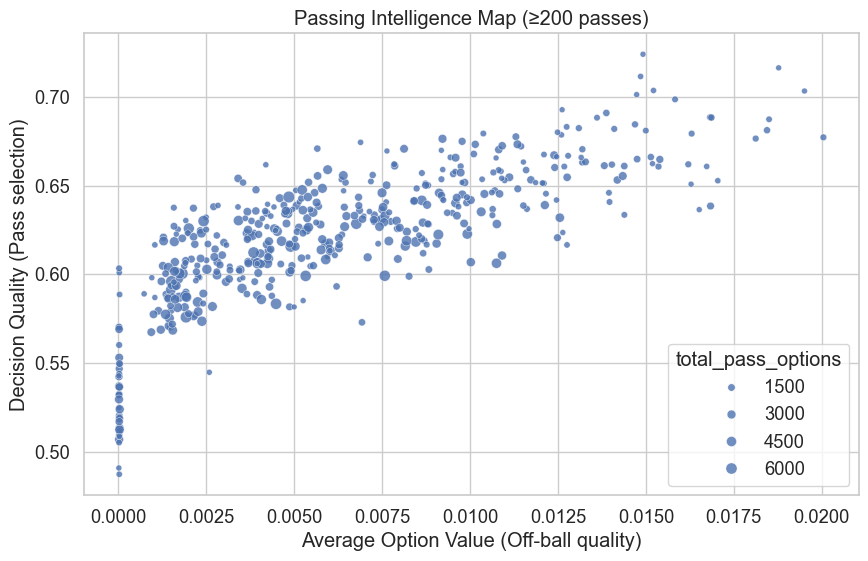

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# 1️⃣ Passer metrics (decision making)
# --------------------------------------------------

passer_metrics = (
    passing_options
    .groupby(["passer_id", "passer_name"])
    .agg(
        total_pass_options=("pass_value", "count"),
        total_pass_value=("pass_value", "sum"),
        avg_pass_value=("pass_value", "mean"),
        avg_decision_quality=("decision_quality", "mean"),
        chose_best_rate=("chose_best", "mean"),
        avg_best_option=("best_pass_value", "mean")
    )
    .reset_index()
)

# Risk taken (how far from optimal pass the player usually goes)
passer_metrics["risk_taken"] = (
    passer_metrics["avg_best_option"] - passer_metrics["avg_pass_value"]
)

# --------------------------------------------------
# 2️⃣ Receiver metrics (option creation)
# --------------------------------------------------

receiver_metrics = (
    passing_options
    .groupby(["player_id", "player_name"])
    .agg(
        times_available=("pass_value", "count"),
        total_option_value=("pass_value", "sum"),
        avg_option_value=("pass_value", "mean"),
        avg_xthreat_option=("xthreat", "mean")
    )
    .reset_index()
)

# --------------------------------------------------
# 3️⃣ Combine both skills
# --------------------------------------------------

players = passer_metrics.merge(
    receiver_metrics,
    left_on=["passer_id", "passer_name"],
    right_on=["player_id", "player_name"],
    how="outer"
)

# --------------------------------------------------
# 4️⃣ Overall passing score
# --------------------------------------------------

players["overall_passing_score"] = (
    players["avg_decision_quality"].fillna(0) *
    players["avg_option_value"].fillna(0)
)

# --------------------------------------------------
# 5️⃣ Filter players with at least 200 passes
# --------------------------------------------------

players_filtered = players[
    players["total_pass_options"] >= 200
].copy()

print("Players with ≥200 passes:", len(players_filtered))

# --------------------------------------------------
# 6️⃣ Best decision makers
# --------------------------------------------------

best_decision_makers = players_filtered.sort_values(
    "avg_decision_quality",
    ascending=False
).head(15)

print("\nBest Decision Makers")
print(best_decision_makers[[
    "passer_name",
    "total_pass_options",
    "avg_decision_quality",
    "chose_best_rate",
    "avg_pass_value"
]])

# --------------------------------------------------
# 7️⃣ Best option creators
# --------------------------------------------------

best_option_creators = players_filtered.sort_values(
    "avg_option_value",
    ascending=False
).head(15)

print("\nBest Passing Option Creators")
print(best_option_creators[[
    "player_name",
    "times_available",
    "avg_option_value",
    "avg_xthreat_option"
]])

# --------------------------------------------------
# 8️⃣ Most complete passing players
# --------------------------------------------------

best_overall = players_filtered.sort_values(
    "overall_passing_score",
    ascending=False
).head(15)

print("\nMost Complete Passing Players")
print(best_overall[[
    "passer_name",
    "avg_decision_quality",
    "avg_option_value",
    "overall_passing_score"
]])

# --------------------------------------------------
# 9️⃣ Passing Intelligence Map
# --------------------------------------------------

sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=players_filtered,
    x="avg_option_value",
    y="avg_decision_quality",
    size="total_pass_options",
    alpha=0.8
)

plt.xlabel("Average Option Value (Off-ball quality)")
plt.ylabel("Decision Quality (Pass selection)")
plt.title("Passing Intelligence Map (≥200 passes)")

plt.show()

C:\Users\vicky\AppData\Local\Temp\ipykernel_16116\1335791376.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_main_and_group)


Players with ≥200 passes: 463


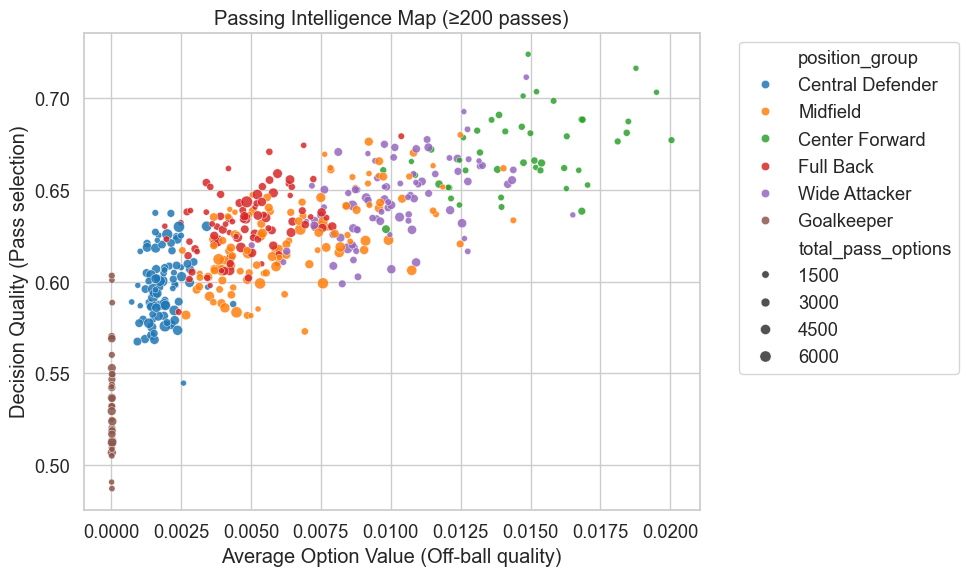

In [24]:
# ==================================================
# LOAD PLAYER POSITION + MINUTES
# ==================================================

players_match = pd.read_parquet(
    r"Datasets/SkillCorner Premier League 24-25 data/players_match.parquet"
)

players_match["player_id"] = players_match["id"]
players_match["player_name"] = players_match["short_name"]
players_match["position"] = players_match["player_role_acronym"]
players_match["position_group"] = players_match["player_role_position_group"]

# ==================================================
# COUNT MATCHES AT EACH POSITION
# ==================================================

position_counts = (
    players_match
    .groupby(["player_id","player_name","team_id","position","position_group"])
    .size()
    .reset_index(name="matches_at_position")
)

# ==================================================
# HANDLE SUBSTITUTES / MAIN POSITION
# ==================================================

position_counts_sorted = position_counts.sort_values(
    ["player_id","matches_at_position"],
    ascending=[True, False]
)

def get_main_and_group(df):

    main_pos = df.iloc[0]["position"]
    sub_flag = 0
    final_pos = main_pos
    final_group = df.iloc[0]["position_group"]

    if main_pos == "SUB":
        sub_flag = 1

        if len(df) > 1:
            final_pos = df.iloc[1]["position"]
            final_group = df.iloc[1]["position_group"]
        else:
            final_pos = "SUB"
            final_group = "SUB"

    if final_pos == "GK":
        final_group = "Goalkeeper"

    return pd.Series({
        "main_position_adjusted": final_pos,
        "SUB": sub_flag,
        "position_group_adjusted": final_group
    })

main_positions_adjusted = (
    position_counts_sorted
    .groupby("player_id")
    .apply(get_main_and_group)
    .reset_index()
)

# ==================================================
# MINUTES PLAYED
# ==================================================

minutes_df = (
    players_match
    .groupby("player_id")
    .agg(
        minutes_played_total=("playing_time_total_minutes_played","sum"),
        minutes_regular_time=("playing_time_total_minutes_played_regular_time","sum")
    )
    .reset_index()
)

minutes_df["per90_factor"] = minutes_df["minutes_played_total"] / 90

# ==================================================
# MAIN POSITION TABLE
# ==================================================

player_main_position = (
    position_counts
    .sort_values("matches_at_position", ascending=False)
    .drop_duplicates("player_id")
)

player_main_position = player_main_position[
    ["player_id","team_id","position","position_group"]
].rename(columns={"position":"main_position"})

# ==================================================
# COMBINE POSITION + MINUTES
# ==================================================

player_info = player_main_position.merge(minutes_df, on="player_id", how="left")
player_info = player_info.merge(main_positions_adjusted, on="player_id", how="left")

player_info["main_position"] = player_info["main_position_adjusted"]
player_info["position_group"] = player_info["position_group_adjusted"]

player_info.drop(
    columns=["main_position_adjusted","position_group_adjusted"],
    inplace=True
)

# ==================================================
# LOAD TEAM NAMES
# ==================================================

matches = pd.read_parquet(
    r"Datasets/SkillCorner Premier League 24-25 data/matches_clean.parquet"
)

team_lookup = pd.concat([
    matches[["home_team_id","home_team_name"]].rename(
        columns={"home_team_id":"team_id","home_team_name":"team_name"}
    ),
    matches[["away_team_id","away_team_name"]].rename(
        columns={"away_team_id":"team_id","away_team_name":"team_name"}
    )
]).drop_duplicates()

player_info = player_info.merge(team_lookup, on="team_id", how="left")

# ==================================================
# MERGE PLAYER INFO WITH PASSING METRICS
# ==================================================

players = players.merge(player_info, on="player_id", how="left")

# ==================================================
# FILTER PLAYERS WITH ≥200 PASSES
# ==================================================

players_filtered = players[
    players["total_pass_options"] >= 200
].copy()

print("Players with ≥200 passes:", len(players_filtered))

# ==================================================
# PASSING INTELLIGENCE MAP
# ==================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=players_filtered,
    x="avg_option_value",
    y="avg_decision_quality",
    hue="position_group",
    size="total_pass_options",
    palette="tab10",
    alpha=0.85
)

plt.xlabel("Average Option Value (Off-ball quality)")
plt.ylabel("Decision Quality (Pass selection)")
plt.title("Passing Intelligence Map (≥200 passes)")

plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()
plt.show()